In [94]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.graphs.utils import *
from src.hyperbolicity.gromov import *
from src.graphs.visualization import *
from collections import Counter
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
def make_cycle(n, start=0):
    """C_n with nodes labeled start..start+n-1."""
    G = nx.cycle_graph(n)
    return nx.relabel_nodes(G, {i: i + start for i in range(n)})

def make_tree(branching, height, start=0):
    """Balanced tree with nodes offset by start."""
    G = nx.balanced_tree(branching, height)
    return nx.relabel_nodes(G, {i: i + start for i in G.nodes()})

def make_tree_of_cycles(cycle_size, n_cycles, branching=2, tree_height=2):
    """
    A balanced tree where each leaf has a cycle C_n attached at one node.

    Returns the composed graph and a dict with component membership:
        {'tree': [node, ...], 'cycles': [[node, ...], ...]}
    """
    tree = make_tree(branching, tree_height, start=0)
    offset = tree.number_of_nodes()

    G = tree.copy()
    leaves = [n for n in tree.nodes() if tree.degree(n) == 1]
    metadata = {'tree': list(tree.nodes()), 'cycles': []}

    for i, leaf in enumerate(leaves[:n_cycles]):
        cycle = make_cycle(cycle_size, start=offset)
        attach_node = offset  # first node of the cycle
        G = nx.compose(G, cycle)
        G.add_edge(leaf, attach_node)
        metadata['cycles'].append(list(cycle.nodes()))
        offset += cycle_size

    return G, metadata

In [98]:
G, metadata = make_tree_of_cycles(cycle_size=8, n_cycles=9, branching=3, tree_height=2)

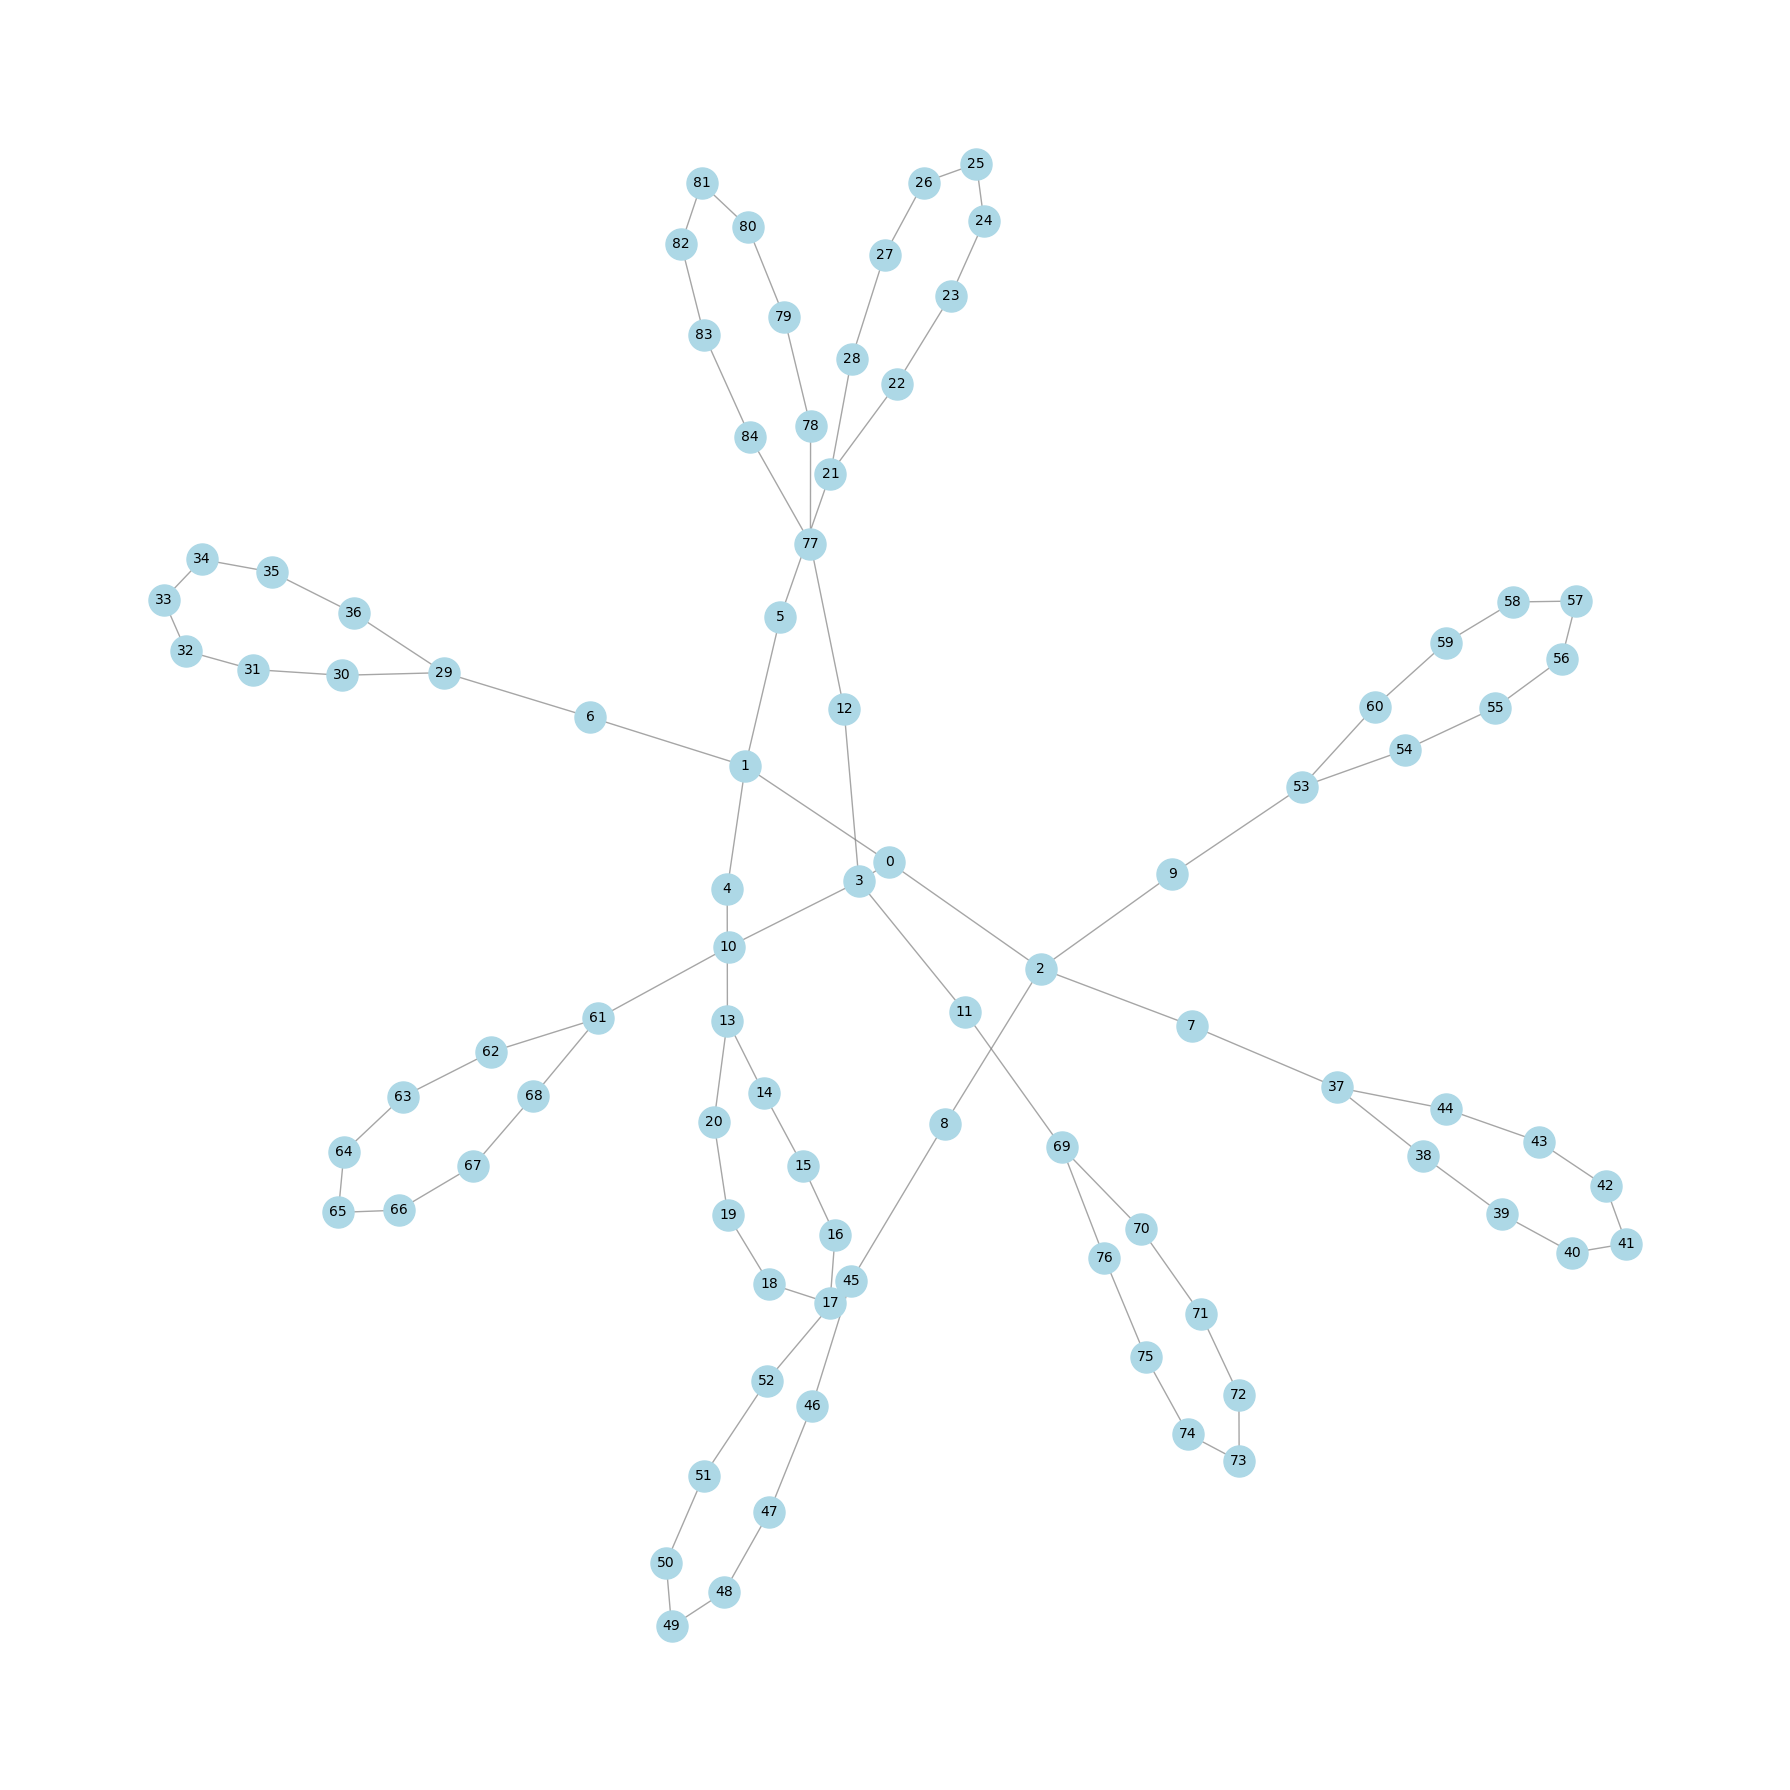

(<Figure size 1800x1800 with 1 Axes>, [<Axes: >])

In [100]:
pos = draw_layout(G)
draw_graphs(G, pos, base_figsize=(18,18))

In [101]:
delta_max, quads = compute_gromov_hyperbolicity(G)
max_quads = [quad for quad, delta in quads.items() if delta == delta_max]
zero_quads = [quad for quad, delta in quads.items() if delta == 0]
delta_distribution = Counter(quads.values())
print(delta_distribution)

Counter({np.float64(0.0): 2011276, np.float64(1.0): 12798, np.float64(2.0): 711})


In [102]:
meta_intra_distance = {}
dists = compute_distance_nodes(G)
for quad in zero_quads:
    meta_intra_distance[quad] = compute_intra_distance(dists,quad)
meta_intra_distance = sorted(meta_intra_distance.items(), key=lambda x: x[1], reverse=True)
print(meta_intra_distance[:10])

[((17, 25, 41, 65), np.float64(13.666666666666666)), ((17, 25, 41, 73), np.float64(13.666666666666666)), ((17, 25, 41, 81), np.float64(13.666666666666666)), ((17, 25, 49, 65), np.float64(13.666666666666666)), ((17, 25, 49, 73), np.float64(13.666666666666666)), ((17, 25, 49, 81), np.float64(13.666666666666666)), ((17, 25, 57, 65), np.float64(13.666666666666666)), ((17, 25, 57, 73), np.float64(13.666666666666666)), ((17, 25, 57, 81), np.float64(13.666666666666666)), ((17, 33, 41, 65), np.float64(13.666666666666666))]


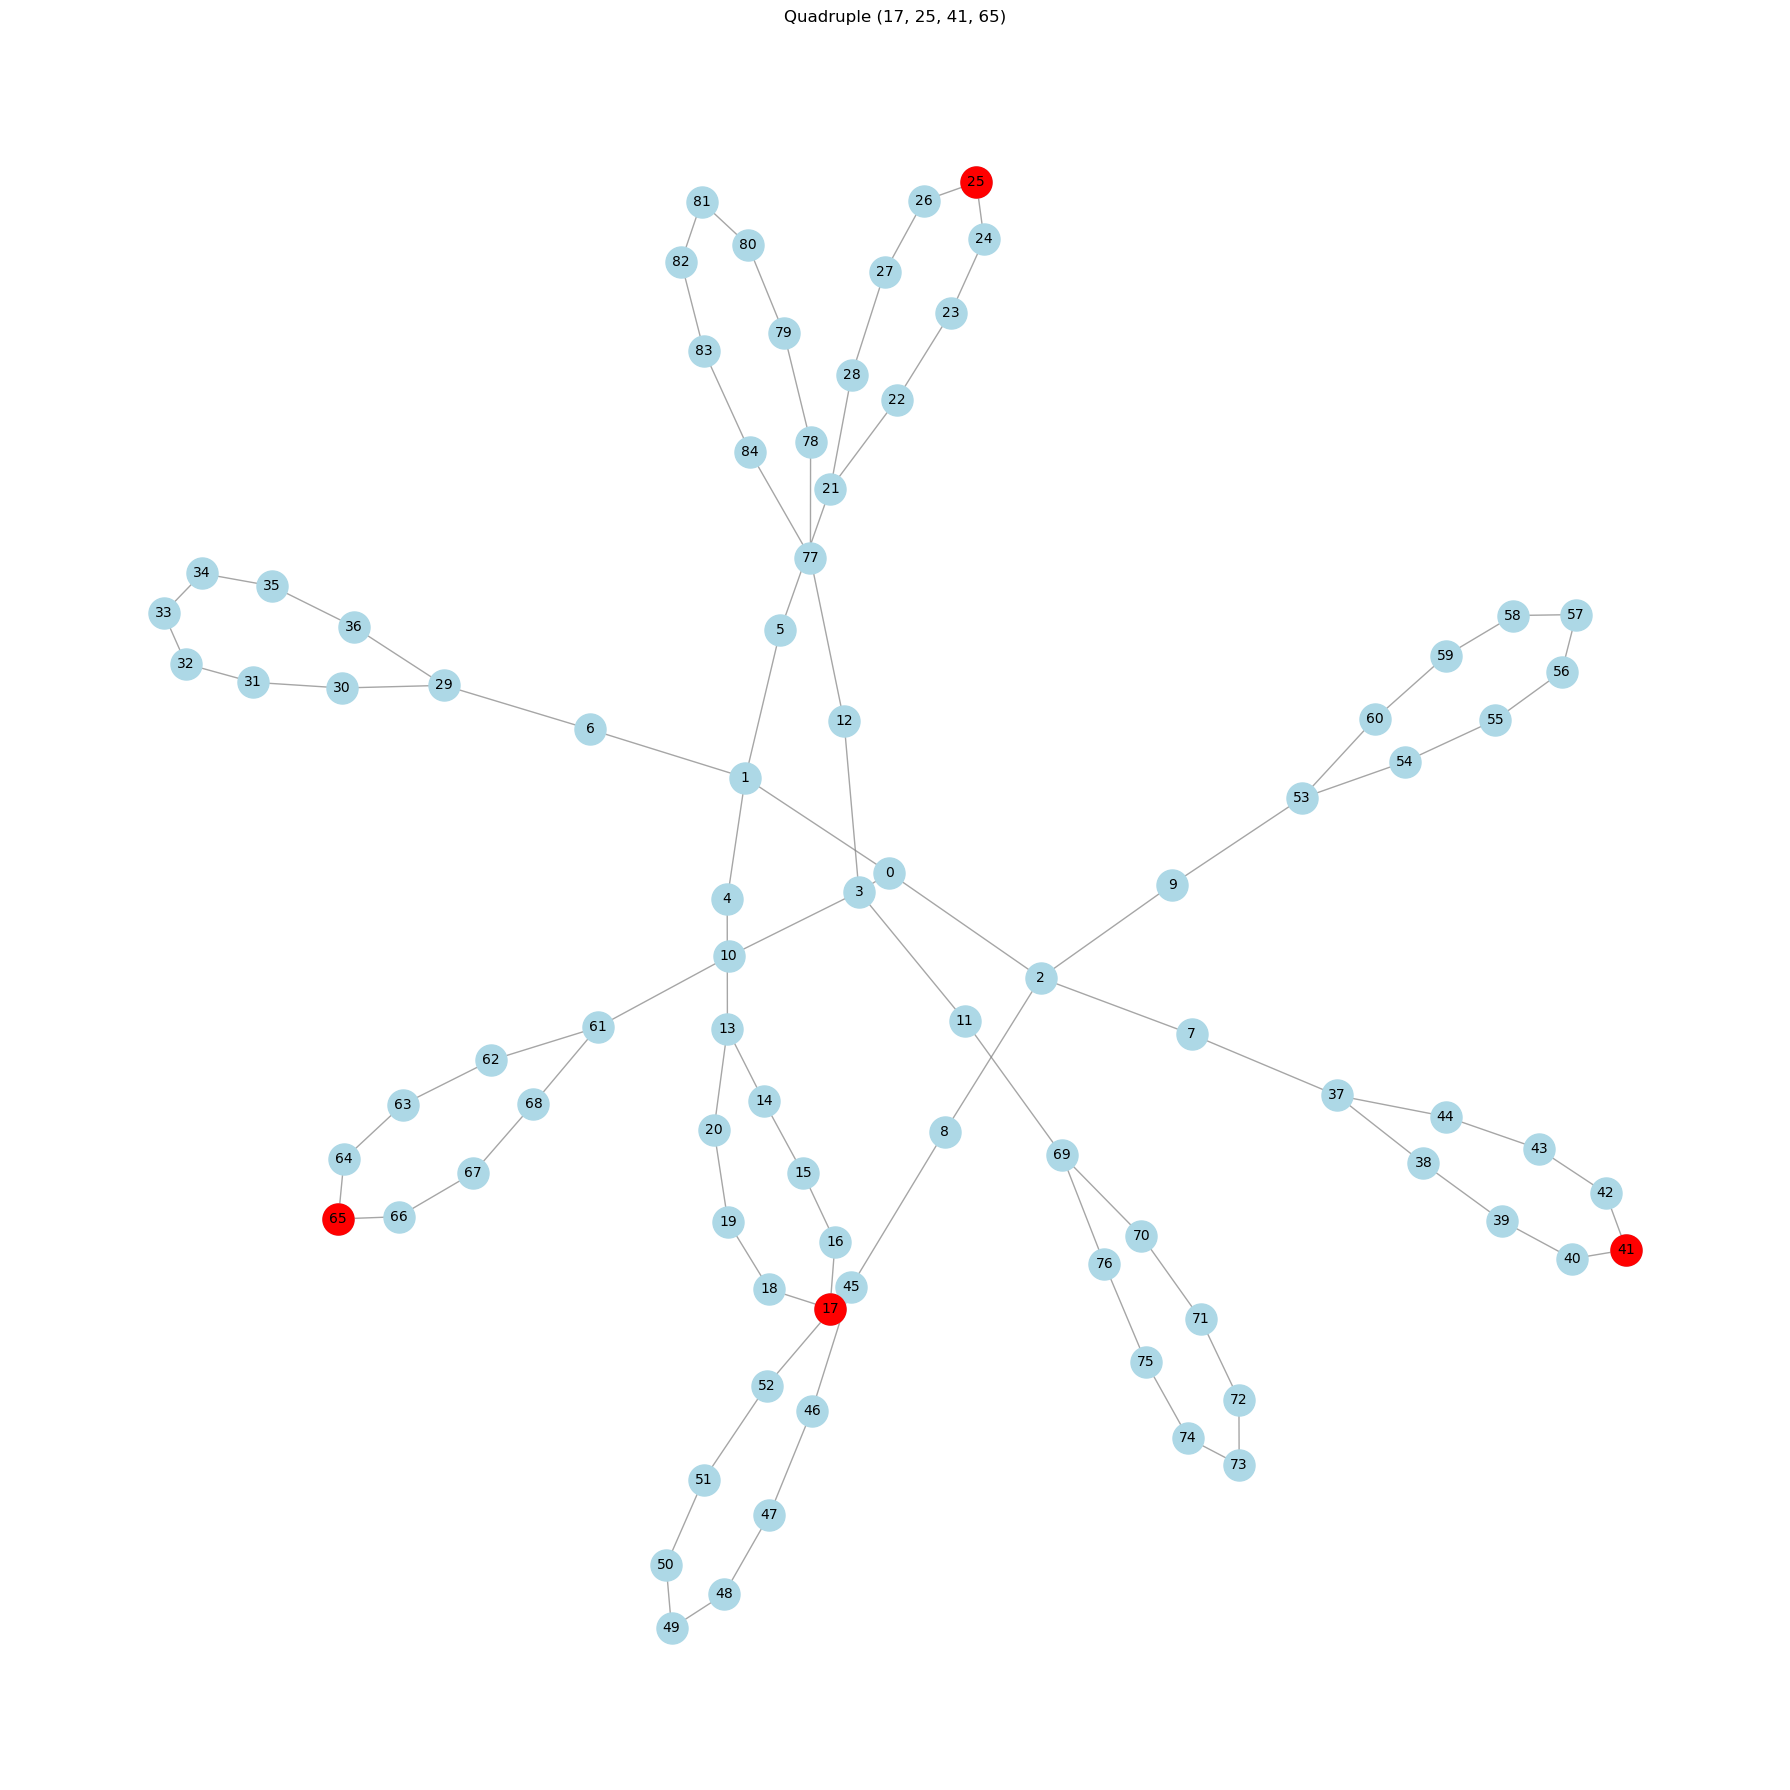

(<Figure size 1800x1800 with 1 Axes>,
 [<Axes: title={'center': 'Quadruple (17, 25, 41, 65)'}>])

In [103]:
quad = meta_intra_distance[0][0]
draw_quadruples(G,pos,[quad], base_figsize=(18,18))

In [73]:
from src.optimization.solver import max_gromov_entropic_distance_regularized
from src.optimization.solver import min_gromov_entropic_distance_regularized

In [104]:
mu, quads = min_gromov_entropic_distance_regularized(G, lambda_reg=1, T=1)

# --- Risultati ---
top_idx = np.argsort(mu)[-5:][::-1]
print(f"{len(quads)} combinations.")
print("-" * 30)
for i in top_idx:
    print(f"Tupla: {quads[i]} | Peso mu: {mu[i]:.6f}")

# Verifica la somma
print("-" * 30)
print(f"The sum of mu is {np.sum(mu):.4f}")

print(f"Different values of mu are: {len(set(mu))}")

2024785 combinations.
------------------------------
Tupla: (0, 2, 7, 8) | Peso mu: 0.000001
Tupla: (1, 4, 5, 6) | Peso mu: 0.000001
Tupla: (0, 3, 10, 12) | Peso mu: 0.000001
Tupla: (0, 3, 10, 11) | Peso mu: 0.000001
Tupla: (0, 3, 11, 12) | Peso mu: 0.000001
------------------------------
The sum of mu is 1.0000
Different values of mu are: 116


In [105]:
k = 10
top_indices = np.argsort(mu)[-k:]
top_quads = [quads[i] for i in top_indices]
top_weights = [mu[i] for i in top_indices]

dists = compute_distance_nodes(G)
for quad in top_quads:
    print(compute_delta_gromov(dists,quad))


0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Claudio\AppData\Local\Temp\ipykernel_21648\1586051503.py:3: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title("Distribution $\mu$")
C:\Users\Claudio\AppData\Local\Temp\ipykernel_21648\1586051503.py:4: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

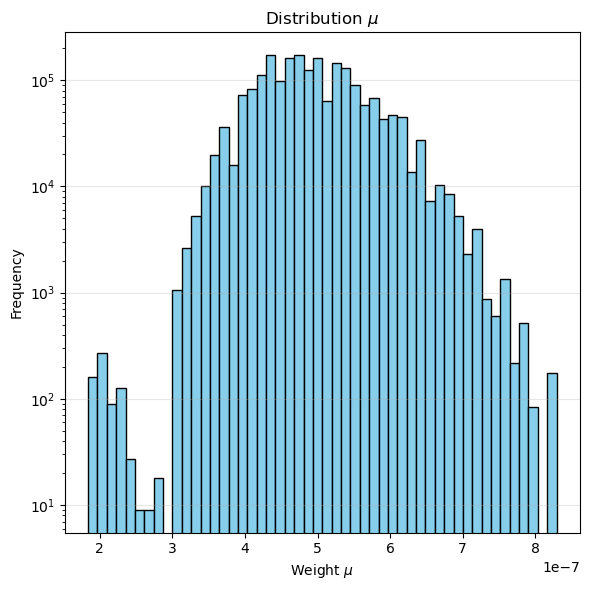

In [106]:
plt.figure(figsize=(6,6))
plt.hist(mu, bins=50, color='skyblue', edgecolor='black', log=True)
plt.title("Distribution $\mu$")
plt.xlabel("Weight $\mu$")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Too many quadruples to visualize (10), showing only the first 9.


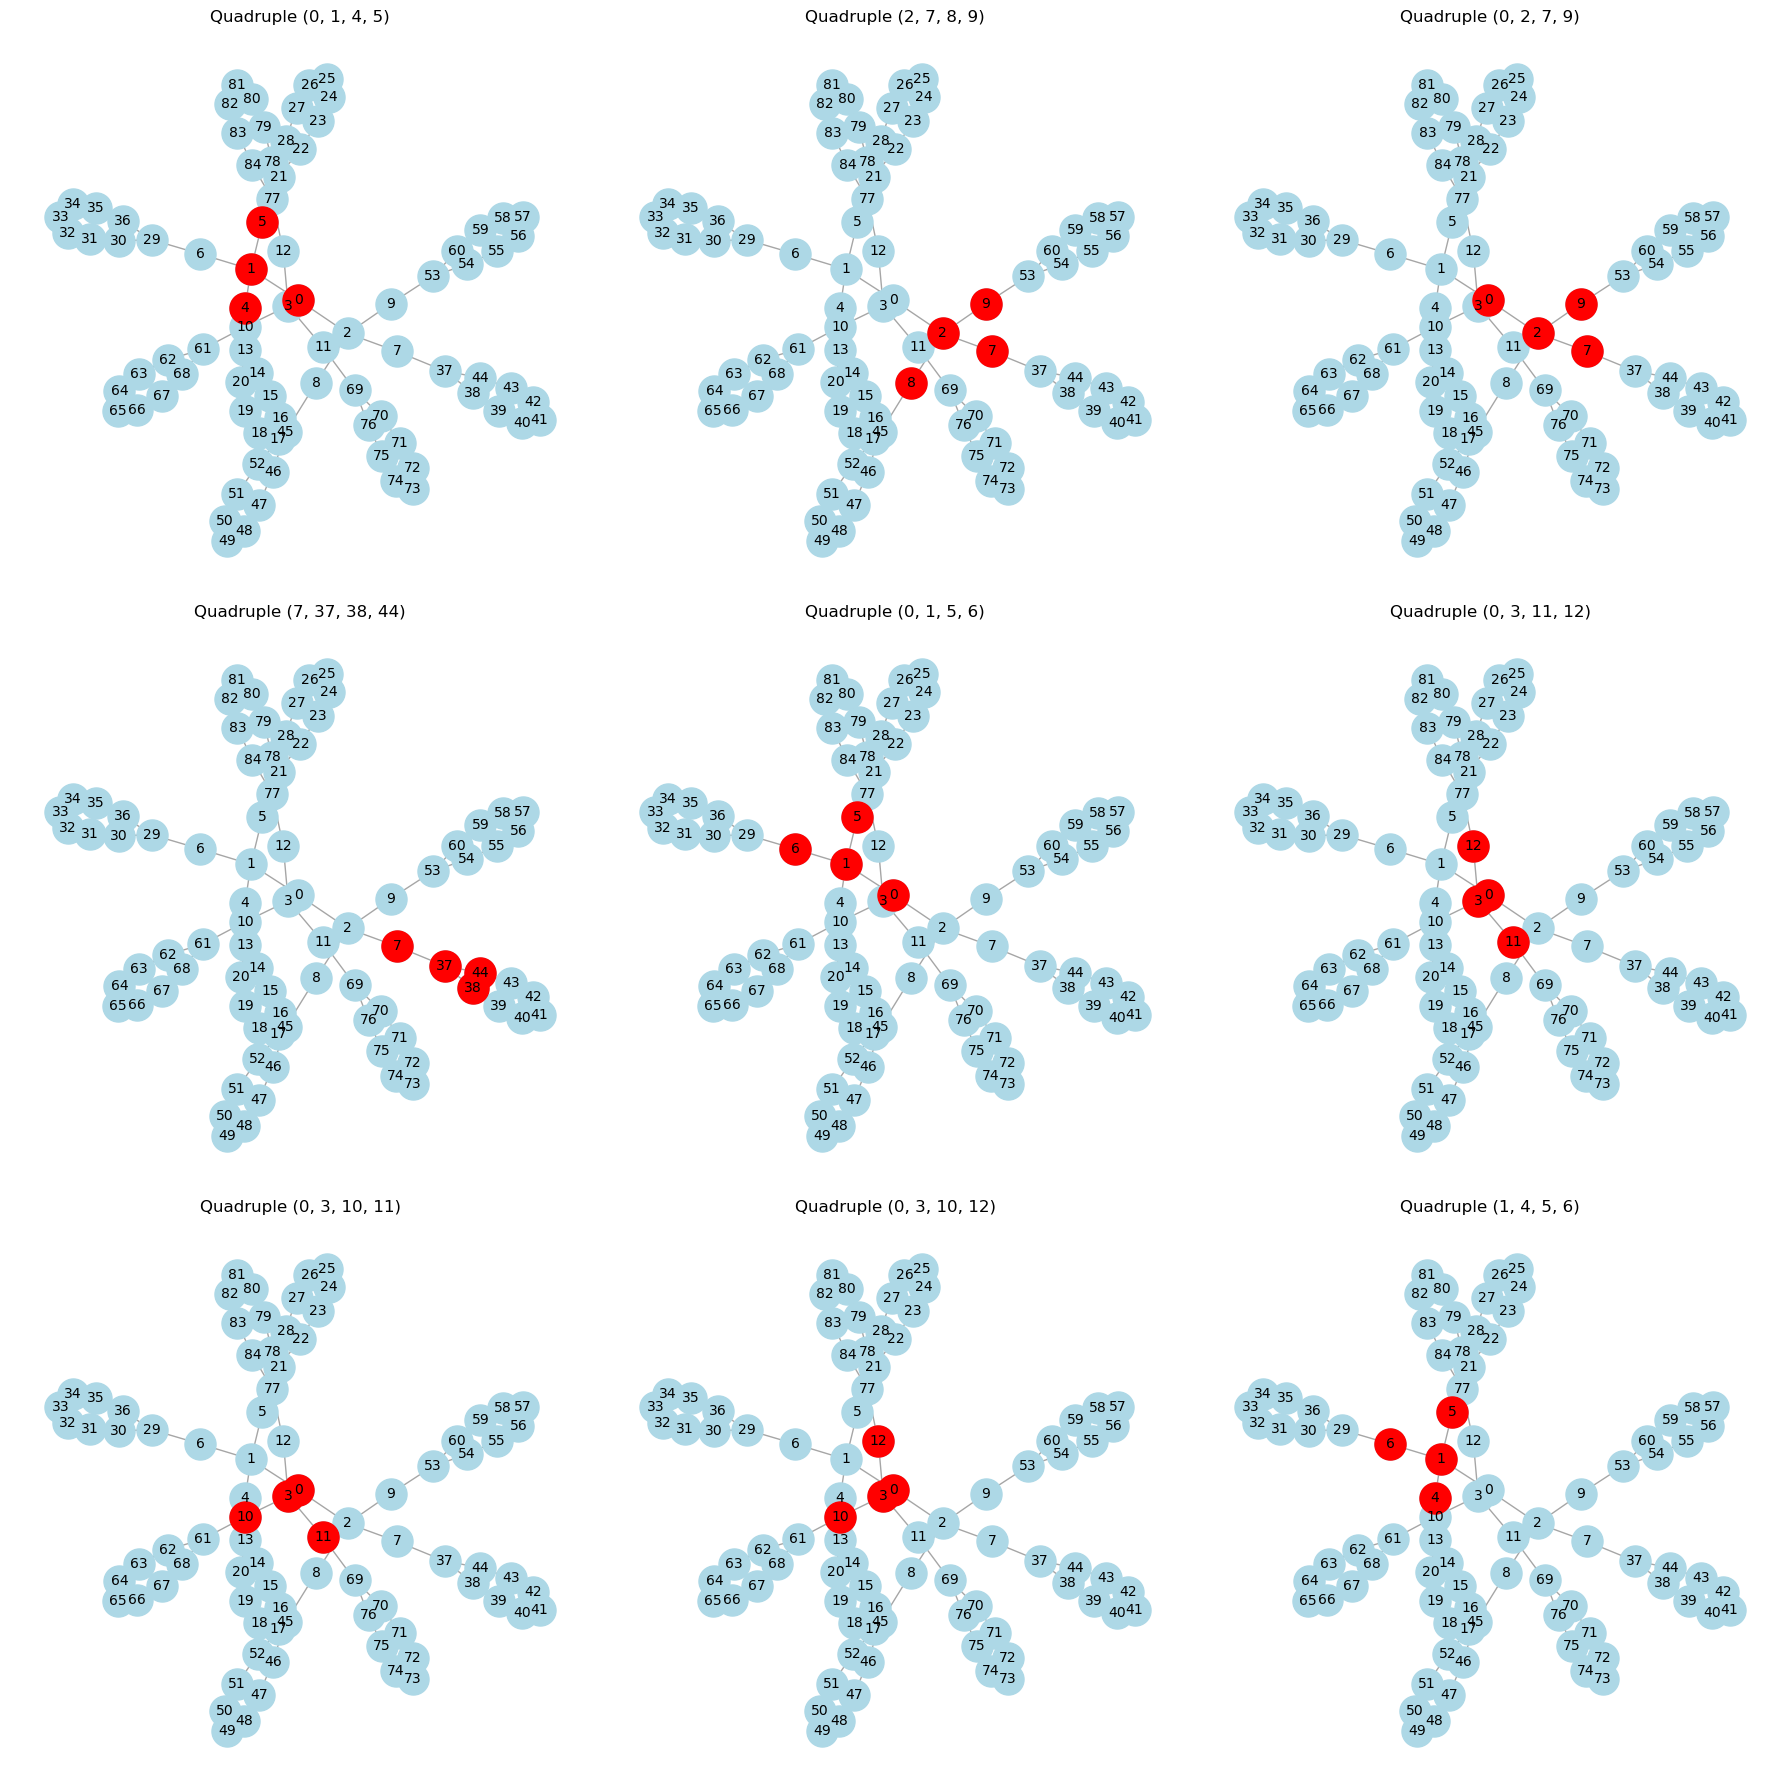

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (0, 1, 4, 5)'}>,
        <Axes: title={'center': 'Quadruple (2, 7, 8, 9)'}>,
        <Axes: title={'center': 'Quadruple (0, 2, 7, 9)'}>,
        <Axes: title={'center': 'Quadruple (7, 37, 38, 44)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 5, 6)'}>,
        <Axes: title={'center': 'Quadruple (0, 3, 11, 12)'}>,
        <Axes: title={'center': 'Quadruple (0, 3, 10, 11)'}>,
        <Axes: title={'center': 'Quadruple (0, 3, 10, 12)'}>,
        <Axes: title={'center': 'Quadruple (1, 4, 5, 6)'}>], dtype=object))

In [107]:
draw_quadruples(G,pos,top_quads)

Delta iperbolicità globale: 3.0


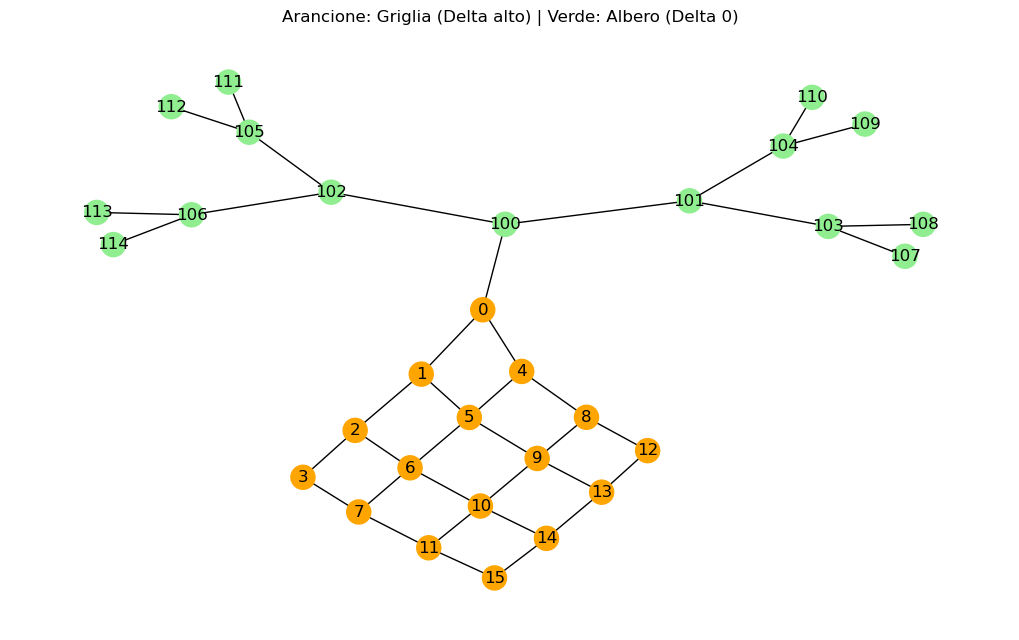

In [77]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools

def compute_gromov_hyperbolicity(G):
    dist = dict(nx.all_pairs_shortest_path_length(G))
    nodes = list(G.nodes())
    delta = 0
    if len(nodes) < 4: return 0
    
    # Nota: su grafi grandi questo è lento. Usiamo un campionamento se necessario.
    for u, v, w, x in itertools.combinations(nodes, 4):
        s1 = dist[u][v] + dist[w][x]
        s2 = dist[u][w] + dist[v][x]
        s3 = dist[u][x] + dist[v][w]
        sums = sorted([s1, s2, s3], reverse=True)
        delta = max(delta, (sums[0] - sums[1]) / 2.0)
    return delta

# 1. Creiamo una Griglia (Zona a BASSA iperbolicità / ALTA delta)
# Una griglia 4x4 non è affatto "tree-like"
grid = nx.grid_2d_graph(4, 4)
grid = nx.relabel_nodes(grid, {node: i for i, node in enumerate(grid.nodes())})

# 2. Creiamo un Albero (Zona ad ALTA iperbolicità / DELTA = 0)
tree = nx.balanced_tree(r=2, h=3)
# Trasliamo gli ID dei nodi dell'albero per non sovrapporli alla griglia
tree = nx.relabel_nodes(tree, {n: n + 100 for n in tree.nodes()})

# 3. Uniamo i due mondi
hybrid_graph = nx.compose(grid, tree)
# Colleghiamo la griglia all'albero con un "ponte"
hybrid_graph.add_edge(0, 100) 

# Calcolo
d_total = compute_gromov_hyperbolicity(hybrid_graph)
print(f"Delta iperbolicità globale: {d_total}")

# Visualizzazione
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(hybrid_graph)
nx.draw(hybrid_graph, pos, with_labels=True, 
        node_color=['orange' if n < 100 else 'lightgreen' for n in hybrid_graph.nodes()],
        node_size=300)
plt.title("Arancione: Griglia (Delta alto) | Verde: Albero (Delta 0)")
plt.show()